### CONEXION DDBB OLIST

In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)



Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


In [8]:
import pandas as pd
from IPython.display import display, Markdown

# Cargar los datos desde SQL (unión con productos, clientes y valoraciones)
query = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    i.seller_id,
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    r.review_score
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
LEFT JOIN olist_customers_dataset c
    ON o.customer_id = c.customer_id
LEFT JOIN olist_order_reviews_dataset r
    ON o.order_id = r.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Convertir las fechas y quedarnos solo con los años 2017 y 2018
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year
df = df[df["order_year"].isin([2017, 2018])]

# Calcular ventas totales por categoría y año
ventas_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(total_sales=("price", "sum"))
      .reset_index()
)

# Calcular número de vendedores únicos
sellers_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(unique_sellers=("seller_id", "nunique"))
      .reset_index()
)

# Calcular número de clientes únicos
customers_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(customers=("customer_unique_id", "nunique"))
      .reset_index()
)

# Calcular clientes que compraron más de una vez en el año
repeat_customers = (
    df.groupby(["product_category_name", "order_year", "customer_unique_id"])
      .agg(order_count=("order_id", "nunique"))
      .reset_index()
)
repeat_customers = (
    repeat_customers[repeat_customers["order_count"] > 1]
    .groupby(["product_category_name", "order_year"])
    .agg(repeat_customers=("customer_unique_id", "nunique"))
    .reset_index()
)

# Promedio de puntuación (review_score) por categoría y año
avg_scores = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(avg_score=("review_score", "mean"))
      .reset_index()
)

# Número total de pedidos por categoría y año
orders_qty = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(orders_qty=("order_id", "nunique"))
      .reset_index()
)

# Crear tablas pivotadas para comparar años
pivot_sales = ventas_anuales.pivot(index="product_category_name", columns="order_year", values="total_sales").fillna(0).reset_index()
pivot_sellers = sellers_anuales.pivot(index="product_category_name", columns="order_year", values="unique_sellers").fillna(0).astype(int).reset_index()
pivot_customers = customers_anuales.pivot(index="product_category_name", columns="order_year", values="customers").fillna(0).astype(int).reset_index()
pivot_repeat = repeat_customers.pivot(index="product_category_name", columns="order_year", values="repeat_customers").fillna(0).astype(int).reset_index()
pivot_scores = avg_scores.pivot(index="product_category_name", columns="order_year", values="avg_score").fillna(0).round(2).reset_index()
pivot_orders = orders_qty.pivot(index="product_category_name", columns="order_year", values="orders_qty").fillna(0).astype(int).reset_index()

# Renombrar columnas para tener sufijos _2017 y _2018
rename_map = {2017: "_2017", 2018: "_2018"}

for pivot, prefix in [
    (pivot_sales, "TotalSales"),
    (pivot_sellers, "UniqueSellers"),
    (pivot_customers, "Customers"),
    (pivot_repeat, "RepeatCustomers"),
    (pivot_scores, "avg_score"),
    (pivot_orders, "OrdersQty")
]:
    for year, suffix in rename_map.items():
        if year in pivot.columns:
            pivot.rename(columns={year: f"{prefix}{suffix}"}, inplace=True)

# Combinar todos los indicadores en un único DataFrame
merged_df = (
    pivot_sales
    .merge(pivot_sellers, on="product_category_name", how="left")
    .merge(pivot_customers, on="product_category_name", how="left")
    .merge(pivot_repeat, on="product_category_name", how="left")
    .merge(pivot_scores, on="product_category_name", how="left")
    .merge(pivot_orders, on="product_category_name", how="left")
)

# Calcular variación porcentual de ventas entre 2017 y 2018
merged_df["delta_sales_pct_2017_2018"] = (
    ((merged_df["TotalSales_2018"] - merged_df["TotalSales_2017"]) /
     merged_df["TotalSales_2017"].replace(0, pd.NA)) * 100
).round(2)

# Ordenar de mayor a menor según ventas de 2018
merged_df = merged_df.sort_values(by="TotalSales_2018", ascending=False)

# Mostrar los primeros resultados
display(Markdown("#### Ventas, clientes, pedidos y valoración media por categoría (2017 → 2018)"))
display(
    merged_df[
        [
            "product_category_name",
            "TotalSales_2017",
            "TotalSales_2018",
            "delta_sales_pct_2017_2018",
            "OrdersQty_2017",
            "OrdersQty_2018",
            "UniqueSellers_2017",
            "UniqueSellers_2018",
            "Customers_2017",
            "Customers_2018",
            "RepeatCustomers_2017",
            "RepeatCustomers_2018",
            "avg_score_2017",
            "avg_score_2018"
        ]
    ].head(20)
)


#### Ventas, clientes, pedidos y valoración media por categoría (2017 → 2018)

order_year,product_category_name,TotalSales_2017,TotalSales_2018,delta_sales_pct_2017_2018,OrdersQty_2017,OrdersQty_2018,UniqueSellers_2017,UniqueSellers_2018,Customers_2017,Customers_2018,RepeatCustomers_2017,RepeatCustomers_2018,avg_score_2017,avg_score_2018
44,health_beauty,481142.73,770002.81,60.04,3382,5375,236,393,3297,5315,82.0,57.0,4.00,4.12
71,watches_gifts,486519.02,708305.95,45.59,2114,3485,58,76,2095,3442,18.0,38.0,3.33,4.00
8,bed_bath_table,497970.94,537514.13,7.94,4496,4898,104,160,4346,4808,139.0,89.0,3.87,3.36
66,sports_leisure,447546.59,530182.18,18.46,3621,4035,285,366,3517,3960,95.0,69.0,2.80,4.21
16,computers_accessories,400490.61,502432.09,25.45,2606,4030,176,206,2567,3957,37.0,70.0,5.00,4.75
50,housewares,227850.67,397688.06,74.54,2439,3399,228,364,2417,3365,20.0,34.0,4.29,2.92
40,furniture_decor,336272.26,385312.01,14.58,3187,3186,246,239,3113,3136,72.0,50.0,5.00,3.64
6,auto,238545.04,346632.44,45.31,1415,2448,179,285,1398,2426,17.0,22.0,5.00,0.00
7,baby,152854.33,256086.70,67.54,1203,1656,110,193,1192,1643,11.0,12.0,3.80,3.00
21,cool_stuff,388971.98,230752.41,-40.68,2200,1409,183,164,2195,1401,5.0,8.0,2.40,5.00


In [10]:
# Seleccionar las 10 categorías con mayores ventas en 2018
top10_sales_2018 = merged_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Crear un subconjunto con las columnas necesarias
growth_df = top10_sales_2018[[
    "product_category_name",
    "UniqueSellers_2017",
    "UniqueSellers_2018",
    "OrdersQty_2017",
    "OrdersQty_2018"
]].copy()

# Calcular el crecimiento porcentual de vendedores
growth_df["sellers_growth_pct"] = (
    ((growth_df["UniqueSellers_2018"] - growth_df["UniqueSellers_2017"]) /
     growth_df["UniqueSellers_2017"].replace(0, pd.NA)) * 100
).round(2)

# Calcular el crecimiento porcentual de pedidos
growth_df["orders_growth_pct"] = (
    ((growth_df["OrdersQty_2018"] - growth_df["OrdersQty_2017"]) /
     growth_df["OrdersQty_2017"].replace(0, pd.NA)) * 100
).round(2)

# Calcular el ratio entre el crecimiento de sellers y el de pedidos
growth_df["ratio_growth_sellers_orders"] = (
    growth_df["sellers_growth_pct"] / growth_df["orders_growth_pct"]
).round(2)

# Ordenar las categorías por mayor crecimiento en pedidos
growth_df = growth_df.sort_values(by="orders_growth_pct", ascending=False)

# Mostrar resultados
display(Markdown("#### Top 10 categorías por ventas 2018 — crecimiento y ratio sellers/orders"))
display(
    growth_df[[
        "product_category_name",
        "sellers_growth_pct",
        "orders_growth_pct",
        "ratio_growth_sellers_orders"
    ]]
)


#### Top 10 categorías por ventas 2018 — crecimiento y ratio sellers/orders

order_year,product_category_name,sellers_growth_pct,orders_growth_pct,ratio_growth_sellers_orders
6,auto,59.22,73.00,0.81
71,watches_gifts,31.03,64.85,0.48
44,health_beauty,66.53,58.93,1.13
16,computers_accessories,17.05,54.64,0.31
50,housewares,59.65,39.36,1.52
7,baby,75.45,37.66,2.00
66,sports_leisure,28.42,11.43,2.49
8,bed_bath_table,53.85,8.94,6.02
40,furniture_decor,-2.85,-0.03,95.00
21,cool_stuff,-10.38,-35.95,0.29


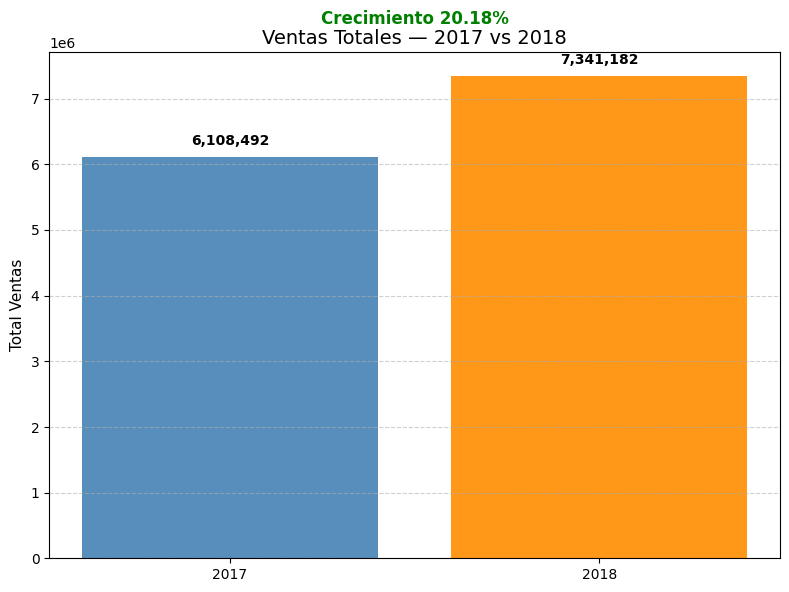

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular el total de ventas por año
total_2017 = merged_df["TotalSales_2017"].sum()
total_2018 = merged_df["TotalSales_2018"].sum()

# Calcular el crecimiento porcentual entre años
growth_pct = ((total_2018 - total_2017) / total_2017) * 100

# Preparar los datos para el gráfico
years = ["2017", "2018"]
totals = [total_2017, total_2018]
x = np.arange(len(years))

# Crear la figura y las barras
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(x, totals, color=["steelblue", "darkorange"], alpha=0.9)

# Añadir etiquetas con los valores sobre las barras
max_height = max(totals)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.02 * max_height),
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.text(
    0.5, max_height * 1.1,
    f"Crecimiento {growth_pct:.2f}%",
    ha="center",
    va="bottom",
    fontsize=12,
    color="green" if growth_pct >= 0 else "red",
    fontweight="bold"
)

# Personalizar el gráfico
ax.set_title("Ventas Totales — 2017 vs 2018", fontsize=14)
ax.set_ylabel("Total Ventas", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ajustar y mostrar
plt.tight_layout()
plt.show()


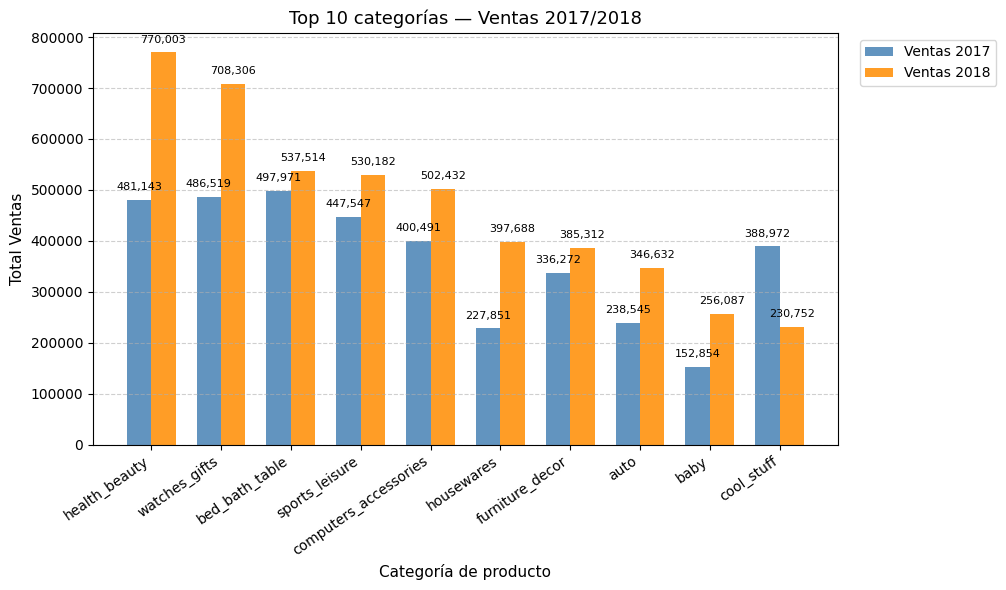

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar las 10 categorías con mayores ventas en 2018
top10_df = merged_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Preparar los datos para el gráfico
categories = top10_df["product_category_name"]
sales_2017 = top10_df["TotalSales_2017"]
sales_2018 = top10_df["TotalSales_2018"]

x = np.arange(len(categories))
width = 0.35  # ancho de las barras

# Crear la figura y los ejes del gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Dibujar las barras de cada año
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Ventas 2017", color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Ventas 2018", color="darkorange", alpha=0.85)

# Añadir etiquetas con los valores encima de cada barra
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Personalizar el gráfico (título, ejes, etiquetas, cuadrícula)
ax1.set_title("Top 10 categorías — Ventas 2017/2018", fontsize=13)
ax1.set_xlabel("Categoría de producto", fontsize=11)
ax1.set_ylabel("Total Ventas", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.6)
ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


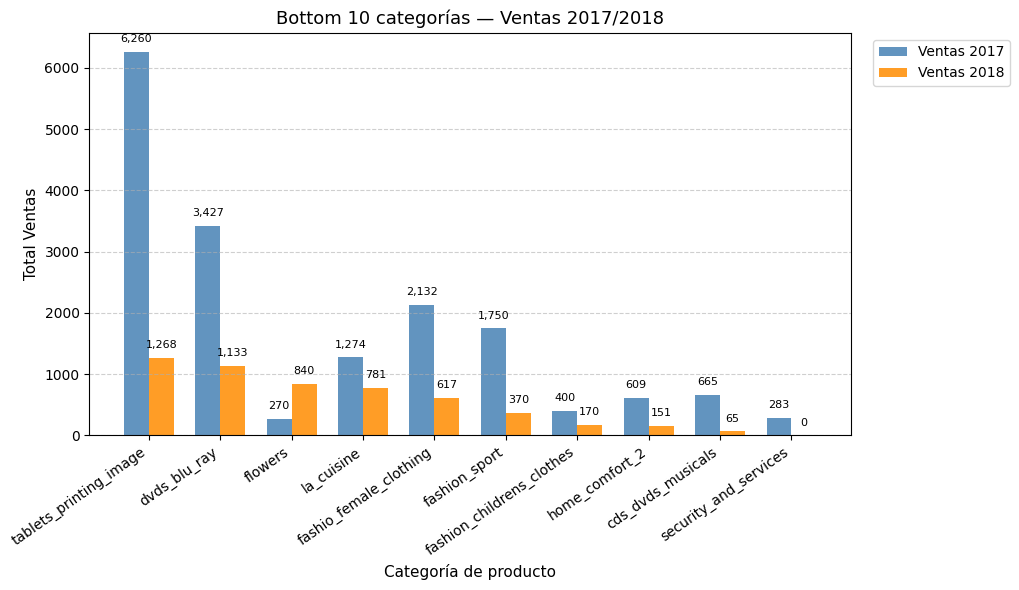

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar las 10 categorías con menores ventas en 2018
bottom10_df = (
    merged_df.sort_values(by="TotalSales_2018", ascending=True)
    .head(10)
    .sort_values(by="TotalSales_2018", ascending=False)  # reordenar de mayor a menor dentro del grupo
)

# Preparar los datos para el gráfico
categories = bottom10_df["product_category_name"]
sales_2017 = bottom10_df["TotalSales_2017"]
sales_2018 = bottom10_df["TotalSales_2018"]

x = np.arange(len(categories))
width = 0.35  # ancho de las barras

# Crear la figura y los ejes del gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Dibujar las barras de ventas de 2017 y 2018
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Ventas 2017", color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Ventas 2018", color="darkorange", alpha=0.85)

# Añadir etiquetas con los valores encima de cada barra
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Personalizar el gráfico: título, ejes, etiquetas y cuadrícula
ax1.set_title("Bottom 10 categorías — Ventas 2017/2018", fontsize=13)
ax1.set_xlabel("Categoría de producto", fontsize=11)
ax1.set_ylabel("Total Ventas", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.6)
ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

# Ajustar el diseño para que no se solape el contenido
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [15]:
# Total de ventas global por año 
totales_por_año = (
    df.groupby("order_year")["price"]
    .sum()
    .reset_index()
    .sort_values("order_year")
)

display(Markdown("### Total de ventas global por año"))
display(totales_por_año)


### Total de ventas global por año

,order_year,price
0,2017,6108492.27
1,2018,7341182.41
